In [111]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [112]:
data = pd.read_csv('../datasets/rs_lettland.csv')
len(data)

1900

In [113]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['target_instances', 'd', 'seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['d', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['d', 'target_instances', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [114]:
mlp_data = pd.read_csv('../results/MLP_ablation_friedman.csv')
print(len(mlp_data))
mlp_data = mlp_data.drop_duplicates()
print(len(mlp_data))

2407
2407


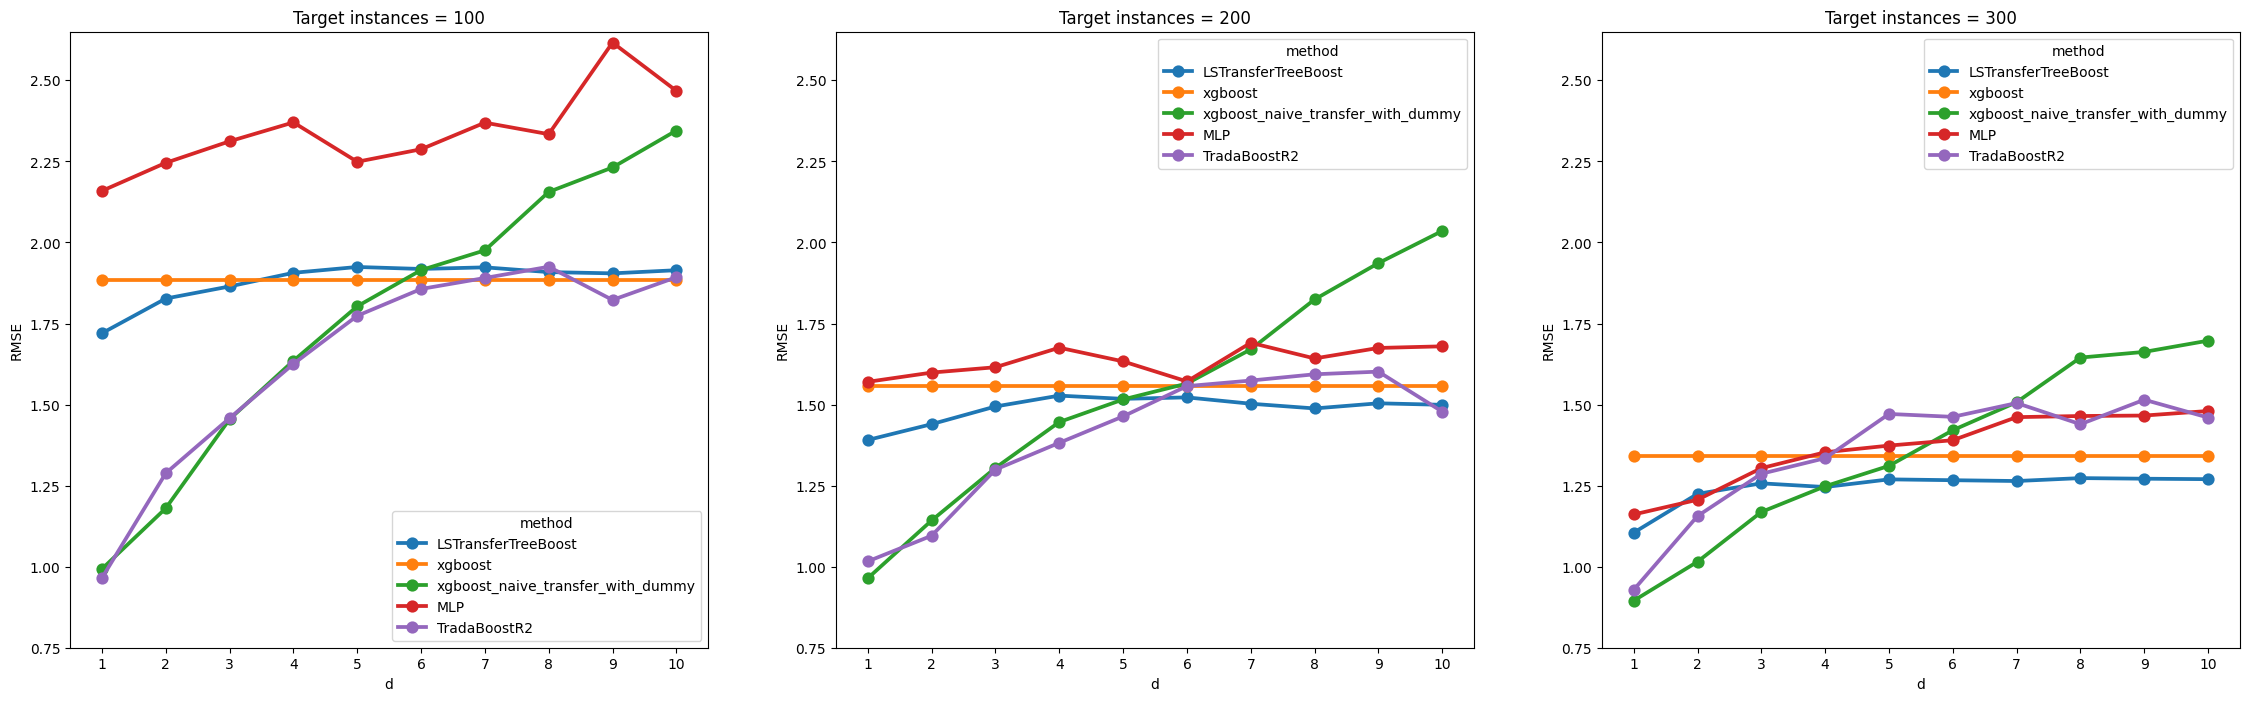

In [115]:
target_instances = 300
best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    f'../results/LSTransferTreeBoost_ablation_friedman.csv',
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)
data = pd.read_csv('results/xgboost_ablation_friedman.csv')
xgboost_data = data[data['method'] == 'xgboost']
naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)

"""
best_naive_transfer, _ = topk_per_d_per_method(
    naive_transfer_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)
"""

best_naive_transfer_with_dummy, _ = topk_per_d_per_method(
    naive_transfer_data_with_dummy,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)


best_mlp, _ = topk_per_d_per_method(
    f'../results/MLP_ablation_friedman.csv',
['target_instances', 'd', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
)


best_tradaboost, _ = topk_per_d_per_method(
    f'../results/trada_ablation_friedman.csv',
['target_instances', 'd', 'n_estimators','lr','tree_size'], k=5
)

target_instances_list = [100,200,300]
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_naive_transfer])
df = pd.concat([df, best_naive_transfer_with_dummy])
df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])
i=0
plt.figure(figsize = (28,8))
for target_instances in target_instances_list:
        plt.subplot(1,3,i+1)
        sns.pointplot(data = df[df['target_instances'] == target_instances], x = 'd', y = 'rmse', hue = 'method', errorbar=None)
        plt.ylabel('RMSE')
        plt.title(f'Target instances = {target_instances}')
        plt.ylim([0.75,2.65])
        i+=1
plt.show()




<Axes: xlabel='d', ylabel='source_tree_size'>

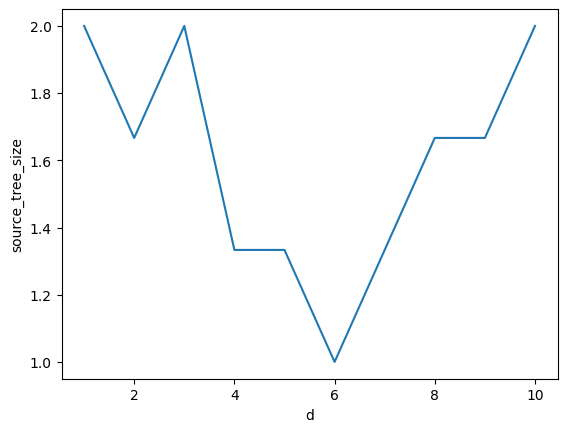

In [116]:
sns.lineplot(data = best_params_for_us, x = 'd', y = 'source_tree_size', errorbar=None)